In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path_to_data = 'Kerala-Rainfall-Historical.csv'
data = pd.read_csv(path_to_data)

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Kerala,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4,3248.6,73.4,386.2,2122.8,666.1
1,Kerala,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5,3326.6,9.3,275.7,2403.4,638.2
2,Kerala,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0,3271.2,21.7,336.3,2343.0,570.1
3,Kerala,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3,3129.7,26.7,339.4,2398.2,365.3
4,Kerala,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2,2741.6,23.4,378.5,1881.5,458.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,Kerala,2013,3.9,40.1,49.9,49.3,119.3,1042.7,830.2,369.7,318.6,259.9,154.9,17.0,3255.4,43.9,218.5,2561.2,431.8
113,Kerala,2014,4.6,10.3,17.9,95.7,251.0,454.4,677.8,733.9,298.8,355.5,99.5,47.2,3046.4,14.9,364.5,2164.8,502.1
114,Kerala,2015,3.1,5.8,50.1,214.1,201.8,563.6,406.0,252.2,292.9,308.1,223.6,79.4,2600.6,8.9,465.9,1514.7,611.1
115,Kerala,2016,3.0,16.4,22.4,33.3,258.4,595.7,441.5,231.0,84.1,105.1,57.9,22.0,1870.9,19.3,314.2,1352.3,185.0


ANNUAL RAINFALL PLOTTING : 
// a plot of year v/s annual rainfall

In [5]:
years = df["YEAR"]
annual_rainfall = df["ANNUAL"]

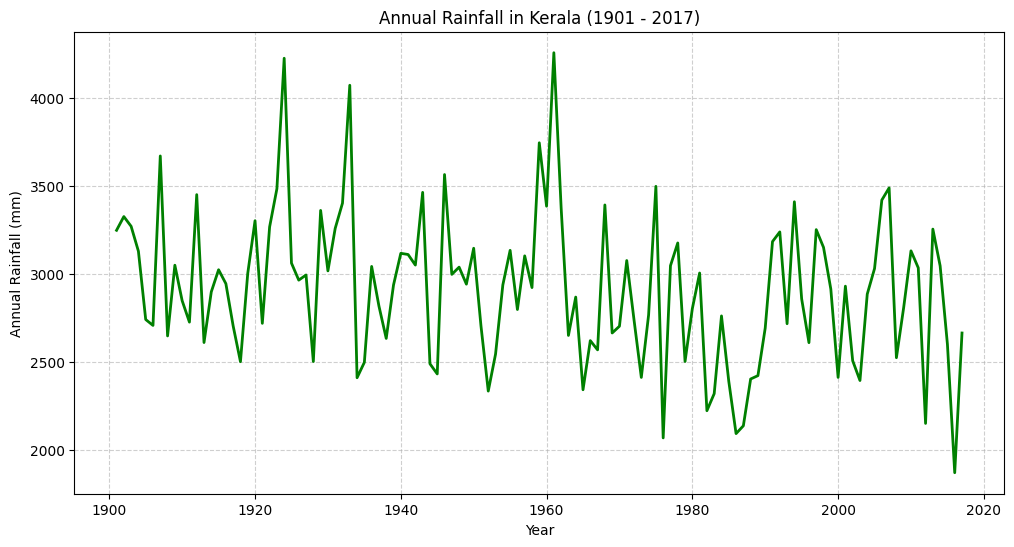

In [6]:
#plotting the line graph for years v/s annual rainfall

plt.figure(figsize=(12,6))
plt.plot(df["YEAR"] , df["ANNUAL"] , color = "green" , linewidth=2)
plt.title("Annual Rainfall in Kerala (1901 - 2017)")
plt.xlabel("Year")
plt.ylabel("Annual Rainfall (mm)")
plt.grid(True, linestyle= "--" , alpha=0.6)
plt.show()

PLOT OF MONSSON SEASON RAINFALL(JJAS - JUNE,JUL, AUG,SEP) V/S ANNUAL RAINFALL

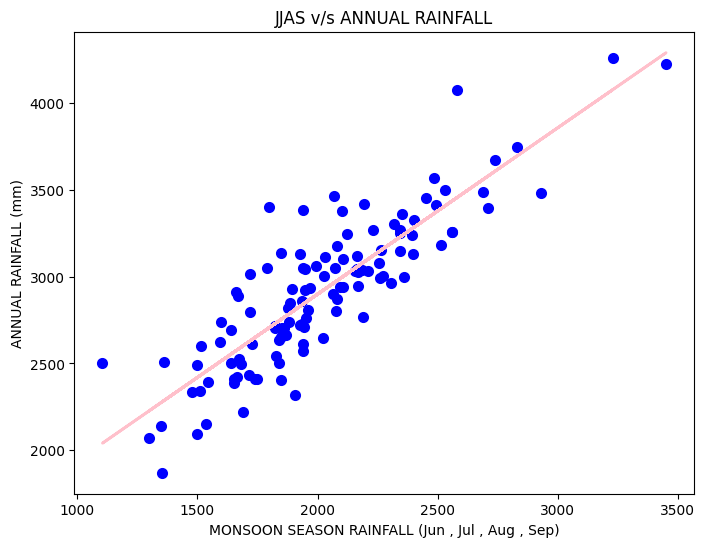

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(df["JJAS"] , df["ANNUAL"] , color="blue" , linewidth=2)
# plotting a regression line through the scatter points using numpy
#Regression line = striaght line , y=-mx+b
x=df["JJAS"]
y=df["ANNUAL"]
m,b = np.polyfit(x,y,1)
plt.plot(x,m*x+b , color="pink",linewidth=2, label="Trendline")
plt.xlabel("MONSOON SEASON RAINFALL (Jun , Jul , Aug , Sep)")
plt.ylabel("ANNUAL RAINFALL (mm)")
plt.title("JJAS v/s ANNUAL RAINFALL")
plt.show()

IDENTIFY YEARS OF EXTREME RAINFALL (JJAS V/S 1649 mm [normal rain])

In [8]:
# we want to detect anomalies - years where rainfall is much higher than normal :
#since floods are caused by monsoon - we use JJAS (instead of annual data)

#computing average rainfall over the years
mean_jjas = df["JJAS"].mean()

#standard deviation 
std_jjas = df["JJAS"].std()

In [9]:
mean_jjas
std_jjas

np.float64(388.17931116200117)

In [10]:
# we are assuming that top 5 %ile are the extreme rainfall categories 
#calculating 95th %ile of JJAS rainfall

threshold = df["JJAS"].quantile(0.95)
print("threshold = " , threshold)
extreme_years = df[df["JJAS"] > threshold][["YEAR" , "JJAS" , "ANNUAL"]]
print("Extreme rainfall years : ")
print(extreme_years)

threshold =  2693.08
Extreme rainfall years : 
    YEAR    JJAS  ANNUAL
6   1907  2737.8  3671.1
22  1923  2928.4  3484.7
23  1924  3451.3  4226.4
58  1959  2831.2  3746.0
60  1961  3229.3  4257.8
67  1968  2711.4  3392.7


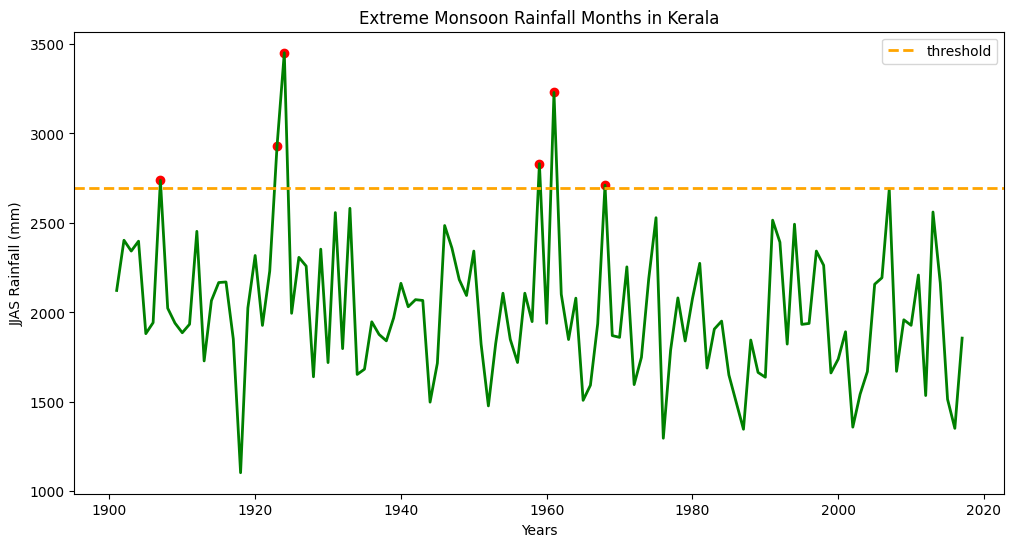

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df["YEAR"] , df["JJAS"] , color="green", linewidth=2)
plt.scatter(extreme_years["YEAR"] , extreme_years["JJAS"] , color = "red")
plt.axhline(y=threshold, color='orange', linestyle='--',linewidth=2,label='threshold')
plt.title("Extreme Monsoon Rainfall Months in Kerala")
plt.xlabel("Years")
plt.ylabel("JJAS Rainfall (mm)")
plt.legend()
plt.show()

COMPARING JJAS RAINFALL ACROSS DECADES | is monsoon intensity rising?

In [12]:
# convert the years by their decade :
df["DECADE"] = (df["YEAR"]//10)*10
df

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND,DECADE
0,Kerala,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4,3248.6,73.4,386.2,2122.8,666.1,1900
1,Kerala,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5,3326.6,9.3,275.7,2403.4,638.2,1900
2,Kerala,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0,3271.2,21.7,336.3,2343.0,570.1,1900
3,Kerala,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3,3129.7,26.7,339.4,2398.2,365.3,1900
4,Kerala,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2,2741.6,23.4,378.5,1881.5,458.1,1900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,Kerala,2013,3.9,40.1,49.9,49.3,119.3,1042.7,830.2,369.7,318.6,259.9,154.9,17.0,3255.4,43.9,218.5,2561.2,431.8,2010
113,Kerala,2014,4.6,10.3,17.9,95.7,251.0,454.4,677.8,733.9,298.8,355.5,99.5,47.2,3046.4,14.9,364.5,2164.8,502.1,2010
114,Kerala,2015,3.1,5.8,50.1,214.1,201.8,563.6,406.0,252.2,292.9,308.1,223.6,79.4,2600.6,8.9,465.9,1514.7,611.1,2010
115,Kerala,2016,3.0,16.4,22.4,33.3,258.4,595.7,441.5,231.0,84.1,105.1,57.9,22.0,1870.9,19.3,314.2,1352.3,185.0,2010


In [13]:
# grouping the data by their decade 
grouped_decade = df.groupby(df["DECADE"])

# we have to find the mean of each decade => we group the decades and then 
# find the mean of the group

decade_avg = df.groupby("DECADE")["JJAS"].mean()   
#==> here ["JJAS"] is imp bcoz we we specifying we only want mean of these months and not of any other column that has been grouped by decades. Decades has grouped every column in the data

print(decade_avg)

DECADE
1900    2199.311111
1910    1938.690000
1920    2341.240000
1930    1962.910000
1940    2067.170000
1950    2003.320000
1960    2081.990000
1970    1918.600000
1980    1790.600000
1990    2100.210000
2000    1887.220000
2010    1890.275000
Name: JJAS, dtype: float64


In [14]:
# here in this new decade dataframe , our index is the decade : we can change it
decade_avg = decade_avg.reset_index()
print(decade_avg)

    DECADE         JJAS
0     1900  2199.311111
1     1910  1938.690000
2     1920  2341.240000
3     1930  1962.910000
4     1940  2067.170000
5     1950  2003.320000
6     1960  2081.990000
7     1970  1918.600000
8     1980  1790.600000
9     1990  2100.210000
10    2000  1887.220000
11    2010  1890.275000


In [15]:
#PLOTTING THE TREND
# presently we have the avg rainfall in JJAS months per year + avg rainfall in JJAS per decade 
# we are plotting :
# JJAS rainfall (mm)  v/s JJAS rainfall per decade  

C:\Users\shara\AppData\Local\Temp\ipykernel_2996\1331825408.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


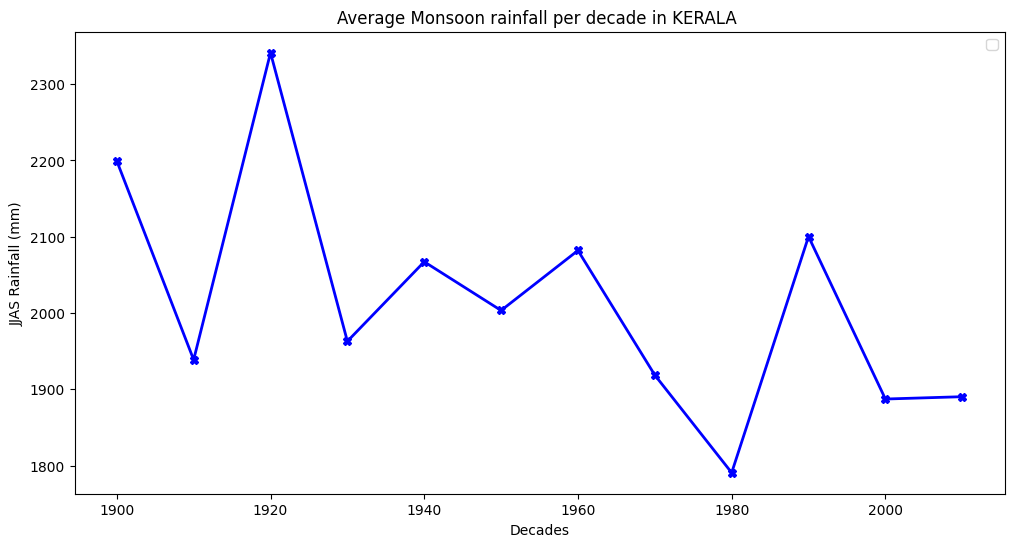

In [16]:
plt.figure(figsize=(12,6))
plt.plot(decade_avg["DECADE"] , decade_avg["JJAS"] , marker = "X" , linewidth=2, color="blue")
plt.title("Average Monsoon rainfall per decade in KERALA ")
plt.xlabel("Decades")
plt.ylabel("JJAS Rainfall (mm)")
plt.legend()
plt.show()

ANALYSIS OF RETREATING MONSOON [OND - OCT,NOV,DEC] | restreating monsoon leads to floods and waterlogging


In [17]:
print(df["OND"])

0      666.1
1      638.2
2      570.1
3      365.3
4      458.1
       ...  
112    431.8
113    502.1
114    611.1
115    185.0
116    441.5
Name: OND, Length: 117, dtype: float64


C:\Users\shara\AppData\Local\Temp\ipykernel_2996\935566713.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


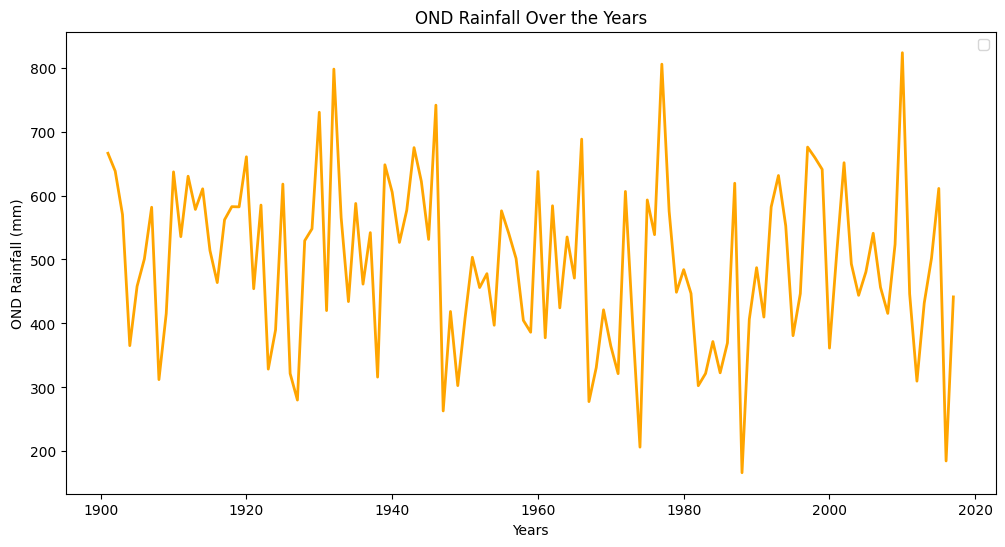

In [18]:
#plotting YEARS v/s OND
plt.figure(figsize=(12,6))
plt.plot(df["YEAR"] , df["OND"] , linewidth=2, color="orange")
plt.title("OND Rainfall Over the Years")
plt.xlabel("Years")
plt.ylabel("OND Rainfall (mm)")
plt.legend()
plt.show()

IDENTIFYING EXTREME OND RAINFALL YEARS AGAINST THRESHOLD (AVG OND RAINFALL)

In [19]:
threshold_ond = df["OND"].quantile(0.95)
print("Threshold OND = ",threshold_ond)
extreme_ond = df[df["OND"]>threshold_ond][["YEAR" , "OND" , "ANNUAL"]]
print(extreme_ond)

Threshold OND =  678.1999999999999
     YEAR    OND  ANNUAL
29   1930  730.2  3018.0
31   1932  797.7  3403.0
45   1946  741.3  3565.5
65   1966  688.2  2621.7
76   1977  805.4  3047.6
109  2010  823.3  3131.8
